In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
def matrix_multiply(A, B):
    rows_A, cols_A = len(A), len(A[0])
    cols_B = len(B[0])
    C = [[0.0] * cols_B for _ in range(rows_A)]
    for i in range(rows_A):
        for j in range(cols_B):
            for k in range(cols_A):
                C[i][j] += A[i][k] * B[k][j]
    return C

In [3]:


sizes = [3 * (2**i) for i in range(8)]
naive_times, numpy_times, labels = [], [], []

for size in sizes:
    np.random.seed(0)
    A_np = np.random.rand(size, size)
    B_np = np.random.rand(size, size)
    labels.append(f"{size}×{size}")

    if size <= 96:
        A_list, B_list = A_np.tolist(), B_np.tolist()
        t0 = time.perf_counter()
        matrix_multiply(A_list, B_list)
        naive_ms = (time.perf_counter() - t0) * 1000
    else:
        naive_ms = None

    t0 = time.perf_counter()
    np.dot(A_np, B_np)
    numpy_ms = (time.perf_counter() - t0) * 1000

    naive_times.append(naive_ms)
    numpy_times.append(numpy_ms)


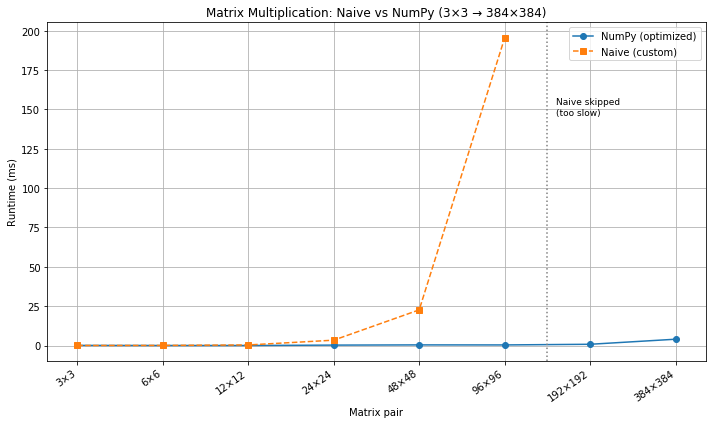

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

measured = [(i, n) for i, n in enumerate(naive_times, 1) if n is not None]
m_x, m_naive = zip(*measured)

ax.plot(range(1, 9), numpy_times, 'o-', label='NumPy (optimized)')
ax.plot(list(m_x), list(m_naive), 's--', label='Naive (custom)')
ax.axvline(x=6.5, color='gray', linestyle=':')
ax.text(6.6, max(m_naive) * 0.75, 'Naive skipped\n(too slow)', fontsize=9)

ax.set_xticks(range(1, 9))
ax.set_xticklabels(labels, rotation=35, ha='right')
ax.set_xlabel('Matrix pair')
ax.set_ylabel('Runtime (ms)')
ax.set_title('Matrix Multiplication: Naive vs NumPy (3×3 → 384×384)')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()